# K562 SEAM foregrounds + annotated seqlets

Auto-detects which single-seq SEAM foregrounds have finished (100k lib / 50 clusters)
and plots each `foreground_scaled.npy` logo with the hand-annotated seqlets overlaid.

Foregrounds are `(200, 4)` = the variable region, so annotation coords (`edits.csv`,
already in var-region space `[0, 200)`) map straight onto the x-axis — no adapter offset.

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, logomaker
from pathlib import Path

FG_ROOT = Path('/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/foregrounds')
SIT     = Path('/grid/koo/home/pmantill/projects/situate/data')

# annotated seqlets/motifs, keyed by situate row index (var-region coords [0,200))
ann = pd.read_csv(SIT / 'annotations/mcs_k562/edits.csv')

# peak name -> situate annotation row, parsed from names.txt (rows 0-2 are the peaks)
PEAK_TO_ANNROW = {}
for row, line in enumerate((SIT / 'mcs_k562/names.txt').read_text().splitlines()):
    tok = line.split()[0]
    if tok.startswith('peak'):
        PEAK_TO_ANNROW[tok] = row
PEAK_TO_ANNROW

{'peak26256': 0, 'peak84030': 1, 'peak27535_Reversed': 2}

In [3]:
# auto-detect finished foregrounds: dir must contain the final foreground_scaled.npy
finished = sorted(d.name for d in FG_ROOT.iterdir()
                  if d.is_dir() and (d / 'foreground_scaled.npy').exists())
print(f'{len(finished)} finished foreground(s):')
for p in finished:
    has = 'annotated' if p in PEAK_TO_ANNROW else 'NO annotations'
    print(f'  {p:24s} {has}')

8 finished foreground(s):
  ENSG00000143384          NO annotations
  peak10288_Reversed       NO annotations
  peak20130                NO annotations
  peak26256                annotated
  peak27535_Reversed       annotated
  peak38192_Reversed       NO annotations
  peak49966_Reversed       NO annotations
  peak84030                annotated


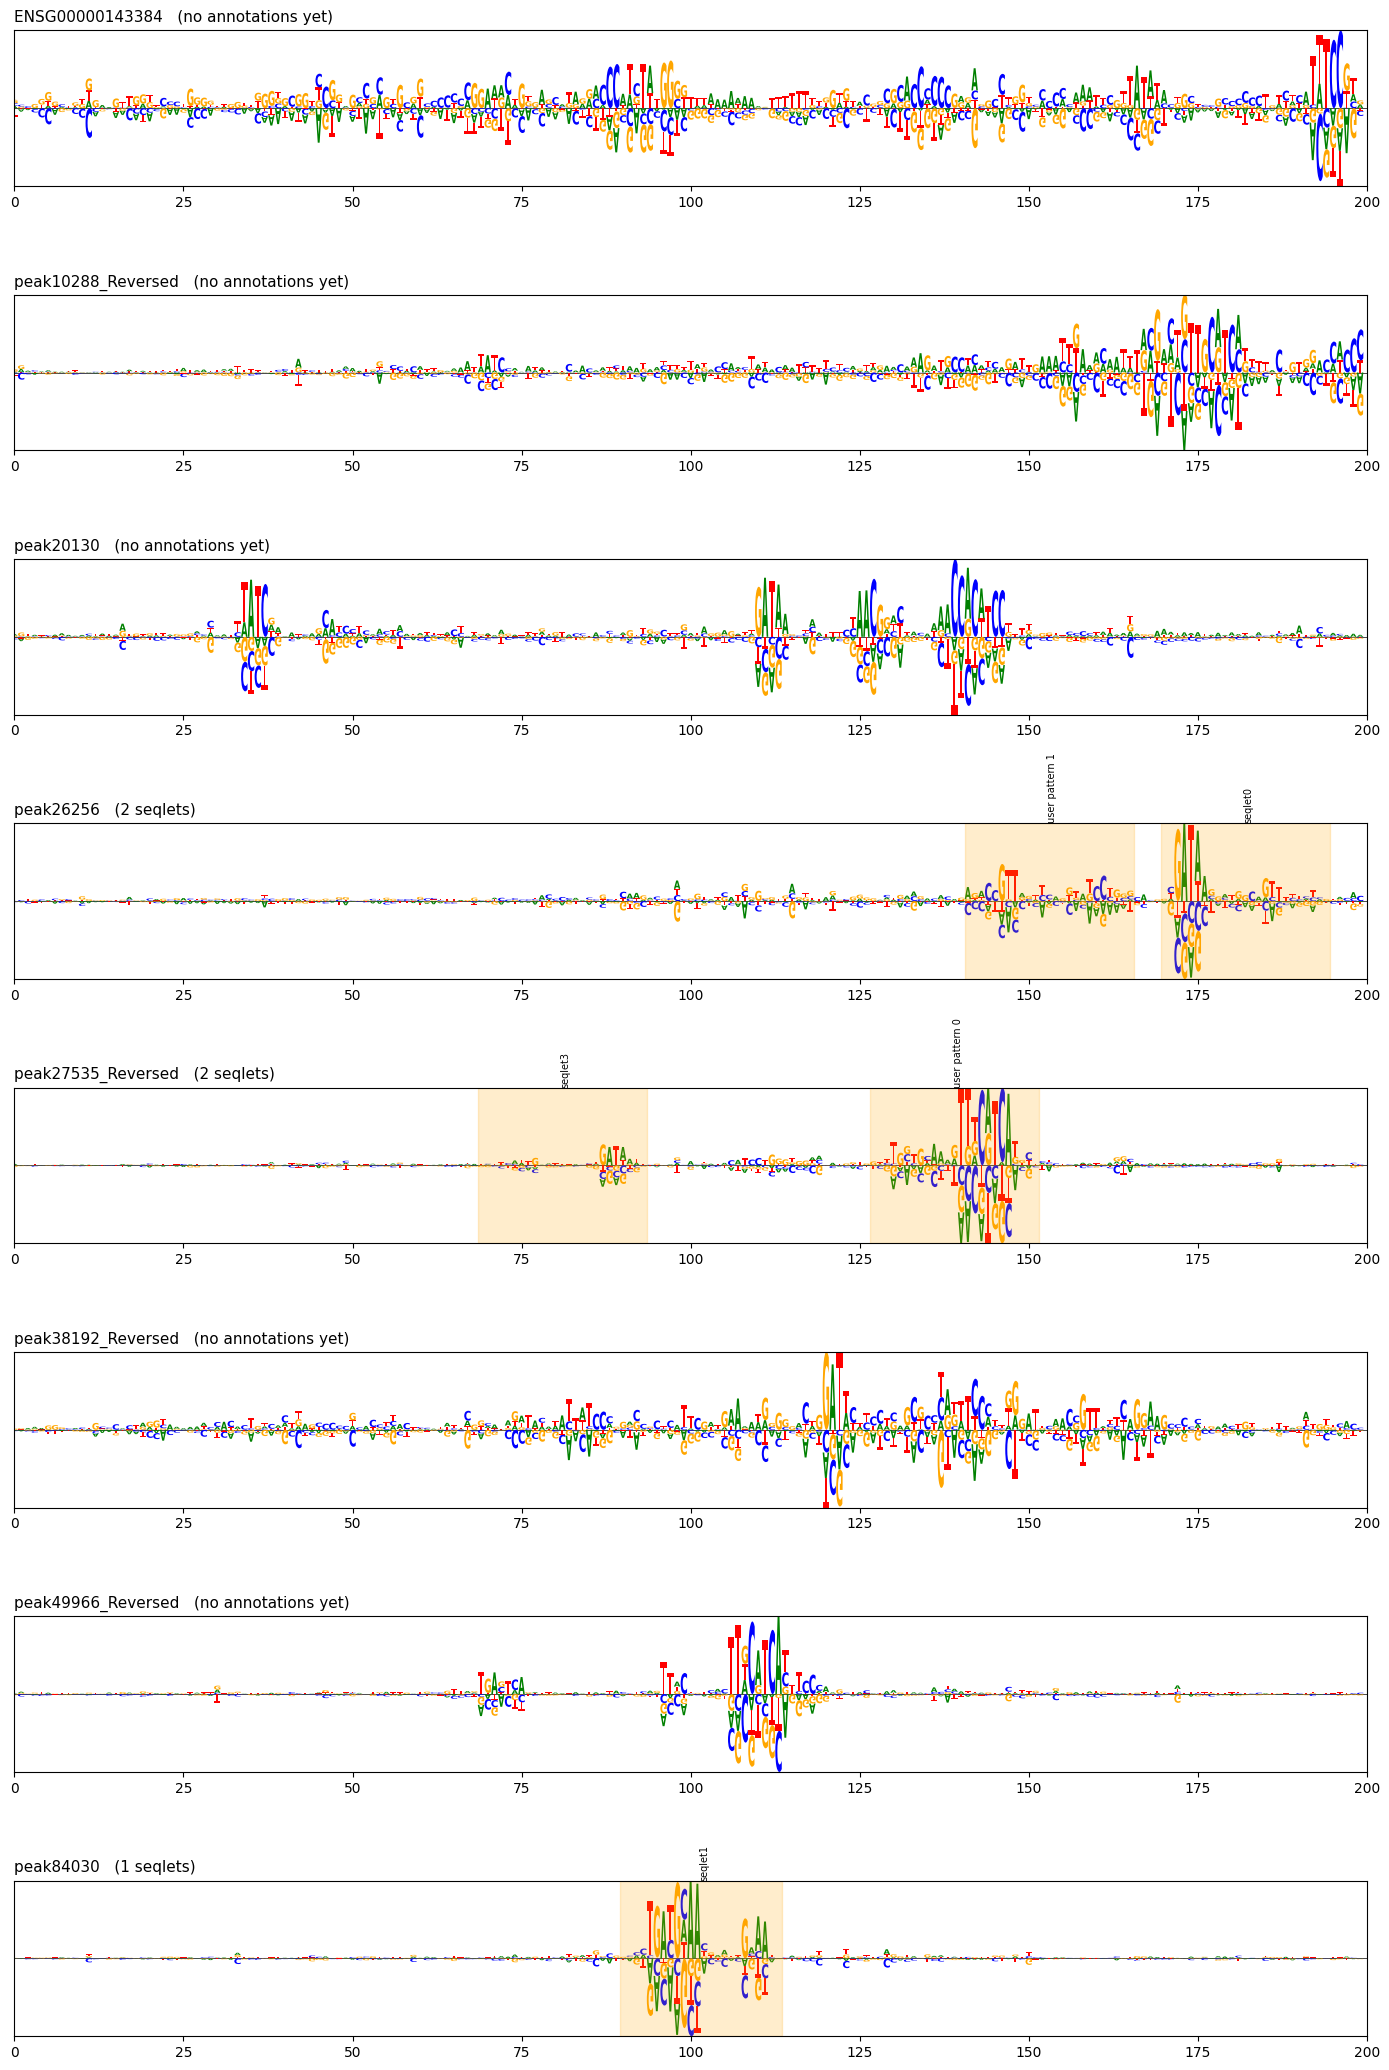

In [4]:
# one foreground logo per finished seq, annotated seqlets overlaid as labelled spans
fig, axes = plt.subplots(len(finished), 1, figsize=(14, 2.6 * len(finished)), squeeze=False)
for ax, peak in zip(axes[:, 0], finished):
    fg = np.load(FG_ROOT / peak / 'foreground_scaled.npy')          # (200, 4)
    logomaker.Logo(pd.DataFrame(fg, columns=list('ACGT')), ax=ax)   # raw 4-channel logo

    row = PEAK_TO_ANNROW.get(peak)
    seqlets = ann[ann.sequence_name == row] if row is not None else ann.iloc[0:0]
    for _, m in seqlets.iterrows():
        ax.axvspan(m.start - 0.5, m.end - 0.5, color='orange', alpha=0.2)
        ax.text((m.start + m.end) / 2, ax.get_ylim()[1], m.motif_name,
                ha='center', va='bottom', fontsize=7, rotation=90)

    tag = f'{len(seqlets)} seqlets' if row is not None else 'no annotations yet'
    ax.set_title(f'{peak}   ({tag})', loc='left', fontsize=11)
    ax.set_yticks([])
    ax.set_xlim(0, 200)
fig.tight_layout()

## KO predictions: motif-syntax vs context vs full KO

Three perturbations per seq, all drawn from the **same 30** variable-region dinuc-shuffles
(constant adapter flanks always kept WT):

- **motif KO** — annotated motifs shuffled, rest of the sequence kept → *motif-syntax box*
- **context KO** — variable-region context shuffled, annotated motifs kept → *context box*
- **full KO** — entire variable region shuffled, nothing kept → *full-shuffle box*

The plot shows **Δ = KO − WT** prediction per replicate (dashed line at 0 = no change;
negative = the knocked-out element was activating). Needs a GPU node (loads the K562 pred_koo encoder).

In [5]:
import sys
# force the SEAM/Hippo build of the encoder (matches the K562 ckpt's HeadConfig)
sys.path.insert(0, '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/'
                   'Hippo_dependency_chromatin-accessibility/alphagenome-encoder-ft/src')
import h5py, torch
from tangermeme.utils import one_hot_encode
from tangermeme.ersatz import dinucleotide_shuffle
from alphagenome_encoder_ft import EncoderMPRAModel

LIB   = Path('/grid/koo/home/pmantill/projects/SEAM_validate/results/single_seq/mutagenesis_lib')
N_REP = 30

CKPT = '/grid/koo/home/shared/models/alphagenome_encoder/torch/mpra_K562/finetuned_encoder.pt'
model = EncoderMPRAModel.from_checkpoint(CKPT, device='cuda').eval()
cfg = torch.load(CKPT, map_location='cpu', weights_only=False)['construct_config']
suffix = one_hot_encode(cfg['promoter_seq'] + cfg['barcode_seq']).float()  # (4,51) promoter+barcode

@torch.no_grad()
def predict_k562(insert_ohe):                       # (B,4,230) -> (B,) K562 pred
    x = torch.cat([insert_ohe, suffix.expand(len(insert_ohe), -1, -1)], 2)  # (B,4,281)
    return model(x.transpose(1, 2).cuda()).cpu().numpy()

ko_peaks = [p for p in finished if p in PEAK_TO_ANNROW]   # only seqs we have motif annotations for
print('context-KO on:', ko_peaks)

context-KO on: ['peak26256', 'peak27535_Reversed', 'peak84030']


In [6]:
# three KO conditions from the SAME 30 var-region shuffles; adapters always stay WT:
#   context KO -> variable-region context shuffled, annotated motifs kept  (context box)
#   motif KO   -> annotated motifs shuffled, rest of the sequence kept     (motif-syntax box)
#   full KO    -> entire variable region shuffled, nothing kept            (full-shuffle box)
wt_pred, ctxko_pred, motifko_pred, fullko_pred = {}, {}, {}, {}
for peak in ko_peaks:
    with h5py.File(LIB / f'{peak}.h5') as f:
        wt_str  = f.attrs['wt_seq_str']
        ADAPTER = int(f.attrs['var_start'])          # variable region = insert[ADAPTER : ADAPTER+200]
    wt     = one_hot_encode(wt_str).float()                                          # (4,230)
    var    = slice(ADAPTER, ADAPTER + 200)
    shuf   = dinucleotide_shuffle(wt[:, var].unsqueeze(0), n=N_REP, random_state=0)[0]  # (30,4,200) var-region shuffles
    motifs = ann[ann.sequence_name == PEAK_TO_ANNROW[peak]]

    # full KO: replace the whole variable region with the shuffle, keep nothing
    full = wt.unsqueeze(0).repeat(N_REP, 1, 1).clone()
    full[:, :, var] = shuf

    # context KO: full-shuffle variable region, then paste motifs back
    ctx = full.clone()
    for _, m in motifs.iterrows():
        ctx[:, :, m.start + ADAPTER : m.end + ADAPTER] = wt[:, m.start + ADAPTER : m.end + ADAPTER]

    # motif KO: keep WT everywhere, replace only the motif positions with the shuffle (shuf is var-indexed)
    mot = wt.unsqueeze(0).repeat(N_REP, 1, 1).clone()
    for _, m in motifs.iterrows():
        mot[:, :, m.start + ADAPTER : m.end + ADAPTER] = shuf[:, :, m.start : m.end]

    wt_pred[peak]      = float(predict_k562(wt.unsqueeze(0))[0])
    fullko_pred[peak]  = predict_k562(full)    # (30,) one per replicate
    ctxko_pred[peak]   = predict_k562(ctx)     # (30,)
    motifko_pred[peak] = predict_k562(mot)     # (30,)
    print(f'{peak:24s} WT={wt_pred[peak]:+.3f}   ctxKO={ctxko_pred[peak].mean():+.3f}   '
          f'motifKO={motifko_pred[peak].mean():+.3f}   fullKO={fullko_pred[peak].mean():+.3f}')

peak26256                WT=+1.732   ctxKO=+1.272   motifKO=-0.487   fullKO=-0.426
peak27535_Reversed       WT=+1.765   ctxKO=+0.497   motifKO=-0.460   fullKO=-0.504
peak84030                WT=+1.795   ctxKO=+0.734   motifKO=-0.062   fullKO=-0.405


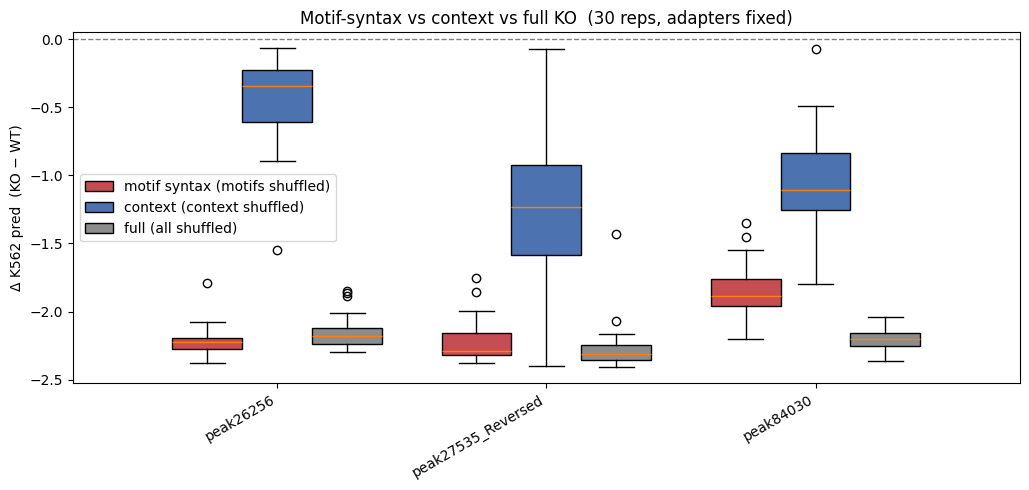

In [7]:
# delta = KO - WT prediction (per replicate); three boxes per seq: motif-syntax / context / full KO
w = 0.26
xg = np.arange(len(ko_peaks))
d_mot  = [motifko_pred[p] - wt_pred[p] for p in ko_peaks]   # motif-syntax box: motifs shuffled, context kept
d_ctx  = [ctxko_pred[p]   - wt_pred[p] for p in ko_peaks]   # context box: context shuffled, motifs kept
d_full = [fullko_pred[p]  - wt_pred[p] for p in ko_peaks]   # full-shuffle box: whole var region shuffled

fig, ax = plt.subplots(figsize=(2.8 * len(ko_peaks) + 2, 5))
b_mot  = ax.boxplot(d_mot,  positions=xg - w, widths=w, patch_artist=True)
b_ctx  = ax.boxplot(d_ctx,  positions=xg,     widths=w, patch_artist=True)
b_full = ax.boxplot(d_full, positions=xg + w, widths=w, patch_artist=True)
for b in b_mot['boxes']:  b.set_facecolor('#c44e52')
for b in b_ctx['boxes']:  b.set_facecolor('#4c72b0')
for b in b_full['boxes']: b.set_facecolor('#8c8c8c')
ax.axhline(0, color='0.5', lw=1, ls='--')
ax.set_xticks(xg); ax.set_xticklabels(ko_peaks, rotation=30, ha='right')
ax.set_ylabel('Δ K562 pred  (KO − WT)')
ax.set_title(f'Motif-syntax vs context vs full KO  ({N_REP} reps, adapters fixed)')
ax.legend([b_mot['boxes'][0], b_ctx['boxes'][0], b_full['boxes'][0]],
          ['motif syntax (motifs shuffled)', 'context (context shuffled)', 'full (all shuffled)'])
fig.tight_layout()

In [24]:
# Rescue the context KO by restoring one dinucleotide class's WT positions, two ways.
# CpG class = CG or GC (both counted per Pablo); AT and AA as literal dinucleotides.
#   A "knock-in"   : full-region shuffle (same as ctxKO) + motifs pasted back + WT dinucs knocked in
#                    -> dinuc positions restored, but dinuc content altered (extra copies added).
#   B "dinuc-kept" : pin the dinucs, dinuc-shuffle only the stretches between, paste motifs back
#                    -> dinuc positions restored AND total dinuc content preserved exactly.
CATS = {'CpG': ('CG', 'GC'), 'AT': ('AT',), 'AA': ('AA',)}

def _load(peak):
    with h5py.File(LIB / f'{peak}.h5') as f:
        wt_str  = f.attrs['wt_seq_str']; ADAPTER = int(f.attrs['var_start'])
    wt     = one_hot_encode(wt_str).float()
    vseq   = wt_str[ADAPTER:ADAPTER + 200].upper()
    motifs = ann[ann.sequence_name == PEAK_TO_ANNROW[peak]]
    shuf   = dinucleotide_shuffle(wt[:, ADAPTER:ADAPTER + 200].unsqueeze(0), n=N_REP, random_state=0)[0]
    return wt, vseq, motifs, ADAPTER, shuf

def _paste_motifs(x, wt, motifs, ADAPTER):
    for _, m in motifs.iterrows():
        x[:, :, m.start + ADAPTER : m.end + ADAPTER] = wt[:, m.start + ADAPTER : m.end + ADAPTER]

def rescue_A(peak, dinucs):                                  # knock-in
    wt, vseq, motifs, ADAPTER, shuf = _load(peak)
    x = wt.unsqueeze(0).repeat(N_REP, 1, 1).clone()
    x[:, :, ADAPTER:ADAPTER + 200] = shuf
    _paste_motifs(x, wt, motifs, ADAPTER)
    for i in range(199):
        if vseq[i:i+2] in dinucs:
            x[:, :, i + ADAPTER : i + ADAPTER + 2] = wt[:, i + ADAPTER : i + ADAPTER + 2]
    return predict_k562(x)

def rescue_B(peak, dinucs):                                  # dinuc-preserving (shuffle around pinned dinucs)
    wt, vseq, motifs, ADAPTER, _ = _load(peak)
    pinned = np.zeros(200, bool)
    for i in range(199):
        if vseq[i:i+2] in dinucs:
            pinned[i:i+2] = True
    segs, i = [], 0
    while i < 200:
        if pinned[i]:
            i += 1; continue
        j = i
        while j < 200 and not pinned[j]:
            j += 1
        segs.append((i, j)); i = j
    x = wt.unsqueeze(0).repeat(N_REP, 1, 1).clone()
    for a, b in segs:
        if b - a < 3:
            continue
        seg = one_hot_encode(vseq[a:b]).float().unsqueeze(0)
        try:
            sh = dinucleotide_shuffle(seg, n=N_REP, random_state=0)[0]
        except (ValueError, RuntimeError):
            continue
        x[:, :, a + ADAPTER : b + ADAPTER] = sh
    _paste_motifs(x, wt, motifs, ADAPTER)
    return predict_k562(x)

rescueA = {c: {p: rescue_A(p, d) for p in ko_peaks} for c, d in CATS.items()}   # knock-in
rescueB = {c: {p: rescue_B(p, d) for p in ko_peaks} for c, d in CATS.items()}   # dinuc-preserving
for c in CATS:
    for p in ko_peaks:
        print(f'{p:22s} {c:3s}  ctxKO={ctxko_pred[p].mean():+.3f}  '
              f'A(knock-in)={rescueA[c][p].mean():+.3f}  B(dinuc-kept)={rescueB[c][p].mean():+.3f}')

peak26256              CpG  ctxKO=+1.272  A(knock-in)=+1.287  B(dinuc-kept)=+1.685
peak27535_Reversed     CpG  ctxKO=+0.497  A(knock-in)=+0.691  B(dinuc-kept)=+1.092
peak84030              CpG  ctxKO=+0.734  A(knock-in)=+1.001  B(dinuc-kept)=+1.461
peak26256              AT   ctxKO=+1.272  A(knock-in)=+1.231  B(dinuc-kept)=+1.417
peak27535_Reversed     AT   ctxKO=+0.497  A(knock-in)=+0.259  B(dinuc-kept)=+1.216
peak84030              AT   ctxKO=+0.734  A(knock-in)=+0.366  B(dinuc-kept)=+1.513
peak26256              AA   ctxKO=+1.272  A(knock-in)=+1.249  B(dinuc-kept)=+1.569
peak27535_Reversed     AA   ctxKO=+0.497  A(knock-in)=+0.333  B(dinuc-kept)=+1.236
peak84030              AA   ctxKO=+0.734  A(knock-in)=+0.561  B(dinuc-kept)=+1.665


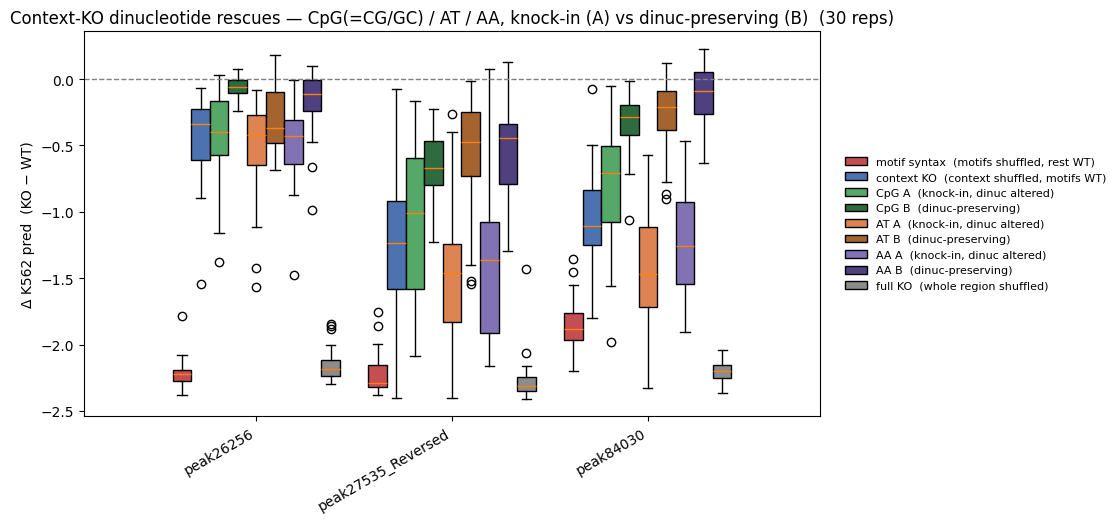

In [25]:
# delta = KO - WT (per rep). Reference boxes (motif / context / full) + per-class rescues:
#   A = knock-in (dinuc positions restored, dinuc content altered)
#   B = dinuc-preserving (dinuc positions restored AND dinuc content kept exact)
w = 0.095
xg = np.arange(len(ko_peaks))
delt = lambda dic: [dic[p] - wt_pred[p] for p in ko_peaks]

# (label, per-seq delta lists, facecolor)
boxes = [('motif syntax  (motifs shuffled, rest WT)',  delt(motifko_pred), '#c44e52'),
         ('context KO  (context shuffled, motifs WT)', delt(ctxko_pred),   '#4c72b0')]
CLASS_COLORS = {'CpG': ('#55a868', '#2e6b3e'), 'AT': ('#dd8452', '#a5642f'), 'AA': ('#8172b3', '#4f4080')}
for c in CATS:
    boxes.append((f'{c} A  (knock-in, dinuc altered)', delt(rescueA[c]), CLASS_COLORS[c][0]))
    boxes.append((f'{c} B  (dinuc-preserving)',        delt(rescueB[c]), CLASS_COLORS[c][1]))
boxes.append(('full KO  (whole region shuffled)', delt(fullko_pred), '#8c8c8c'))

n = len(boxes)
fig, ax = plt.subplots(figsize=(3.6 * len(ko_peaks) + 2, 5))
handles = []
for k, (lab, data, col) in enumerate(boxes):
    b = ax.boxplot(data, positions=xg + (k - (n - 1) / 2) * w, widths=w, patch_artist=True)
    for box in b['boxes']:
        box.set_facecolor(col)
    handles.append(b['boxes'][0])
ax.axhline(0, color='0.5', lw=1, ls='--')
ax.set_xticks(xg); ax.set_xticklabels(ko_peaks, rotation=30, ha='right')
ax.set_ylabel('Δ K562 pred  (KO − WT)')
ax.set_title(f'Context-KO dinucleotide rescues — CpG(=CG/GC) / AT / AA, knock-in (A) vs dinuc-preserving (B)  ({N_REP} reps)')
ax.legend(handles, [lab for lab, _, _ in boxes],
          loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
fig.subplots_adjust(right=0.7)